# 03 - Bonus: K-Means Clustering (Unsupervised Validation)

The core deliverable of this project is the rule-based RFM segmentation in
`02_rfm_segmentation.py` — named segments are directly actionable by a
marketing team without translation. This notebook asks a follow-up
question: **does an unsupervised method discover roughly the same
structure?** If K-Means clusters line up with our named segments, that's
independent evidence the rule-based segments reflect real behavioral
groups rather than an arbitrary scoring convention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RFM_PATH = "../data/processed/rfm_segments.csv"
OUTPUT_PATH = "../data/processed/rfm_kmeans_clusters.csv"

BAR_COLOR = "#2a78d6"
INK_PRIMARY = "#0b0b0b"
INK_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
CATEGORICAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]

plt.rcParams.update({
    "axes.edgecolor": GRID_COLOR,
    "axes.labelcolor": INK_MUTED,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY,
    "font.size": 10,
})

rfm = pd.read_csv(RFM_PATH)
rfm[["Recency", "Frequency", "Monetary"]].skew()

Recency       1.242934
Frequency    11.951208
Monetary     19.578200
dtype: float64

## 1. Transform & scale features

Frequency and Monetary are heavily right-skewed (a small number of bulk
buyers dominate the raw scale) — K-Means uses Euclidean distance, so an
untransformed skew would let those few customers dominate every centroid.
We log-transform, then standardize all three to zero mean / unit variance.

In [2]:
features = rfm[["Recency", "Frequency", "Monetary"]].copy()
features["Frequency"] = np.log1p(features["Frequency"])
features["Monetary"] = np.log1p(features["Monetary"])

scaler = StandardScaler()
X = scaler.fit_transform(features)

## 2. Determine the optimal number of clusters

Two independent diagnostics: the Elbow method (inertia — look for where
adding clusters stops meaningfully reducing within-cluster variance) and
the Silhouette score (how well-separated clusters are; higher is better).
We pick the K that maximizes Silhouette, using Elbow as a sanity check.

In [3]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k = list(k_range)[int(np.argmax(silhouettes))]
print(f"Best K by silhouette score: {best_k}")

Best K by silhouette score: 3


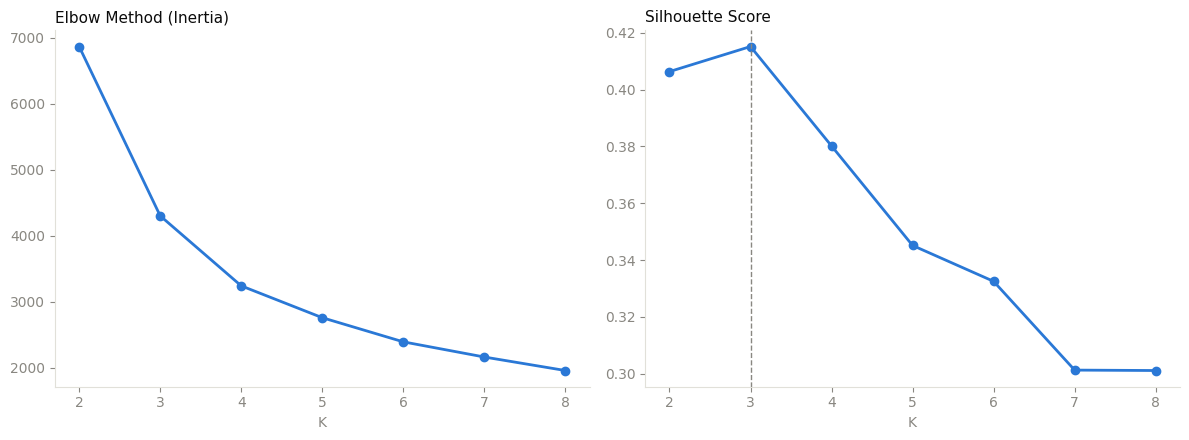

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(list(k_range), inertias, marker="o", color=BAR_COLOR, linewidth=2)
axes[0].set_title("Elbow Method (Inertia)", loc="left", fontsize=11, color=INK_PRIMARY)
axes[0].set_xlabel("K")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(list(k_range), silhouettes, marker="o", color=BAR_COLOR, linewidth=2)
axes[1].axvline(best_k, color=INK_MUTED, linestyle="--", linewidth=1)
axes[1].set_title("Silhouette Score", loc="left", fontsize=11, color=INK_PRIMARY)
axes[1].set_xlabel("K")
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../outputs/kmeans_optimal_k.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Fit the final K-Means model

In [5]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(X)

cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "nunique"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
).round(1).sort_values("Avg_Monetary", ascending=False)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
1,1328,30.2,9.7,5361.1
2,2020,54.5,2.0,602.4
0,986,255.0,1.4,405.4


## 4. Compare against the rule-based RFM segments

For each cluster, which named segment is most common? This is the actual
validation step — if clusters map cleanly onto one or two dominant named
segments, the two independent methods agree on the underlying structure.

In [6]:
comparison = pd.crosstab(rfm["Cluster"], rfm["Segment"])
comparison["Top_Segment"] = comparison.idxmax(axis=1)
comparison["Top_Segment_Pct"] = (comparison.drop(columns="Top_Segment").max(axis=1) /
                                   comparison.drop(columns="Top_Segment").sum(axis=1) * 100).round(1)

comparison[["Top_Segment", "Top_Segment_Pct"]]

Segment,Top_Segment,Top_Segment_Pct
Cluster,,
0,Hibernating,78.1
1,Loyal Customers,44.7
2,Potential Loyalists,22.7


## 5. Visualize clusters in Recency x Monetary space

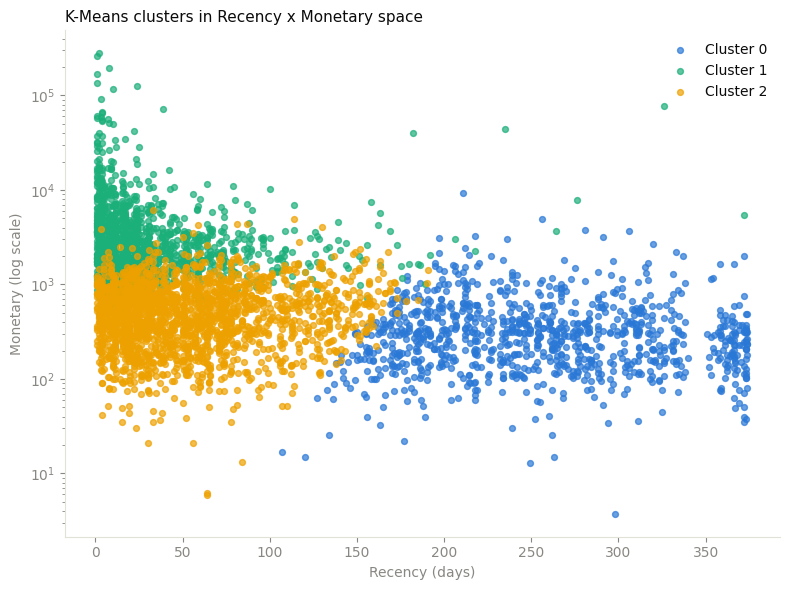

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for cluster_id in sorted(rfm["Cluster"].unique()):
    subset = rfm[rfm["Cluster"] == cluster_id]
    ax.scatter(subset["Recency"], subset["Monetary"], s=18, alpha=0.7,
               color=CATEGORICAL[cluster_id % len(CATEGORICAL)],
               label=f"Cluster {cluster_id}")

ax.set_yscale("log")
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Monetary (log scale)")
ax.set_title("K-Means clusters in Recency x Monetary space", loc="left", fontsize=11, color=INK_PRIMARY)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("../outputs/kmeans_clusters_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Export

In [8]:
rfm.to_csv(OUTPUT_PATH, index=False)
print(f"Saved cluster assignments to {OUTPUT_PATH}")

Saved cluster assignments to ../data/processed/rfm_kmeans_clusters.csv
